In [1]:
%env NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/
import sys

env: NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/


In [7]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random

from alertstack.analyse import Analyse
from alertstack.fixed_catalogues.icecube_neutrino_alerts import (
    HealpixNeutrinoAlertCatalogue
)
from alertstack.scramble_catalogues.agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)

from alertstack.scramble_catalogues.flaires_catalogue import (
    FlairesCatalogue, FluencebolHypothesis
)
from alertstack.scramble_catalogues.sjoert_catalogue import (
    AccretionFlaresSjoertCatalogue, StrengthFluxWeightHypothesis
)
#from alertstack.scramble_catalogues.blazar_catalogue import (
#    Fermi4FGLBlazarCatalogue, AverageFluxWeightHypothesis
#)
from scipy import interpolate
from scipy.optimize import bisect
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

In [3]:
def find_sens(
    catalog,
    hypos,
    nucat,
    min_E,
    cache_dir,
    old_res_path,
    fraction=0.3,
    n_steps=15,
    n_trials=50,
    progression_bar=True,
    tag="",
    max_workers=4,
    chunksize=4,
):
    additional_tag = f"{tag}_E_min_{min_E}"
    analysis = Analyse(
        catalog,
        hypos,
        nucat,
        cache_dir=cache_dir,
        min_E = min_E,
        clean_cache=False
    )
    analysis.set_injection_hypo(hypos[0], min_E)
    fs = [0. for i in range(n_trials)]
    min_frac = 0.0
    for step in np.linspace(min_frac, fraction, n_steps + 1)[1:]:
        fs += [step for _ in range(n_trials)]
    
    inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]
    
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
        )
    print(results)
    
    all_res = dict()
    
    # Combine results into nested dictionaries
    
    for fraction in sorted(list(set(fs))):
        mask = np.array(fs) == fraction
        cut_results = np.array(results)[mask]
        res_dict = cut_results[0]
        for entry in cut_results[1:]:
            for key, val in entry.items():
                res_dict[key] += val
    
        for key in res_dict.keys():
            res_dict[key] = np.array(res_dict[key])
        all_res[fraction] = res_dict
    
    analysis.all_res = all_res
    
    analysis.dump_results(additional_tag=additional_tag)

    results = glob.glob(analysis.cache_dir + "/" + additional_tag + "*")
    new_res = results[0]
    old_res = old_res_path
    
    with open(new_res, "rb") as f:
        new_res_dict = pickle.load(f)
    with open(old_res, "rb") as f:
        old_res_dict = pickle.load(f)
    
    sens_threshold = dict()
    for key, val in old_res_dict[0.].items():
        sens_threshold[key] = np.median(val)

    levels = [
        ("Background Median", sens_threshold),
    ]
    print(levels)
    
    above = dict()
    
    # Calculate for each step the fraction of trials that are above a certain threshold
    # and store the information in the 'above' dictionary
    for step, res in new_res_dict.items():
    
        bkgs = dict()
        temp = []
    
        for key, val in res.items():
            val = np.array(val)
    
            for name, thresh in levels:
                temp.append(np.sum(val > thresh[key])/float(len(val)))        
        above[step] = temp
    
    fracs = list(above.keys())
    sens = [list(above.values())[i][0] for i in range(len(fracs))]
    
    # Interpolate a curve to the data points of the fraction of trials above each threshold
    f1 = interpolate.interp1d(fracs, sens, kind='cubic')
    
    frs = np.linspace(min(fracs), max(fracs), 100)
    plt.scatter(fracs, sens, marker="o")
    plt.plot(frs, f1(frs))
    plt.axhline(0.9, color="red", linestyle="dotted")
    plt.axvline(0.012, color="black", linestyle="dotted")
    plt.show()
    plt.close()
    
    # Calculate average signalness and number of neutrino alerts
    tmp = [i.weight for i in analysis.fixed_sources]
    avg_signalness = np.mean(tmp)
    n_events = len(tmp)
    
    # Calculate flux needed to achieve sensitivity and discovery potential 
    print(
        "\n------- Sensitivity and discovery potential with "
        "{0} neutrino alerts (average signalness: {1:.1f} %, min_E: {2:.0f} TeV) --------\n".format(
            n_events, 100*avg_signalness, min_E
        )
    )
    
    x1 = bisect(
        lambda x: f1(x)-0.9,
        min_frac,
        fraction,
        xtol=1e-6
    )
    
    print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
                x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
    print("\n----------------------------------------------------------------------------------------------------------\n")

    return x1

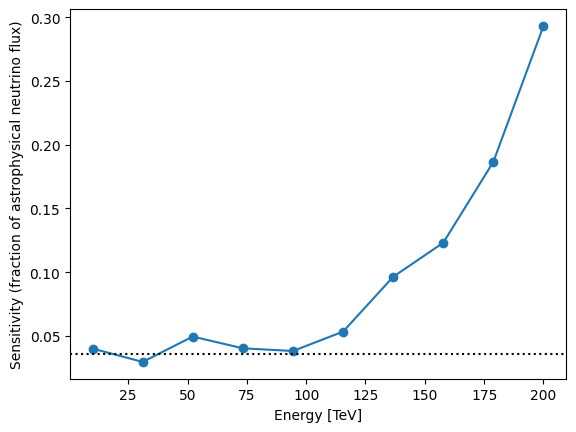

In [6]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.036, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.savefig("e_min_radio_agn", dpi=150)

100%|██████████| 1600/1600 [01:06<00:00, 24.23it/s]


[{'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [3.4268951182241243]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.43966582661391496]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_

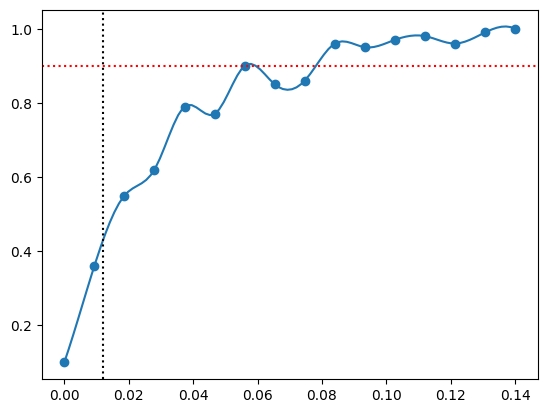


------- Sensitivity and discovery potential with 73 neutrino alerts (average signalness: 45.6 %, min_E: 50 TeV) --------

Sensitivity at 0.078 of flux, expectation of 2.6/73 = 0.04

----------------------------------------------------------------------------------------------------------



100%|██████████| 1600/1600 [01:08<00:00, 23.42it/s]


[{'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.16638625926632775]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [2.005355793043894]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.6194724321065627]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]

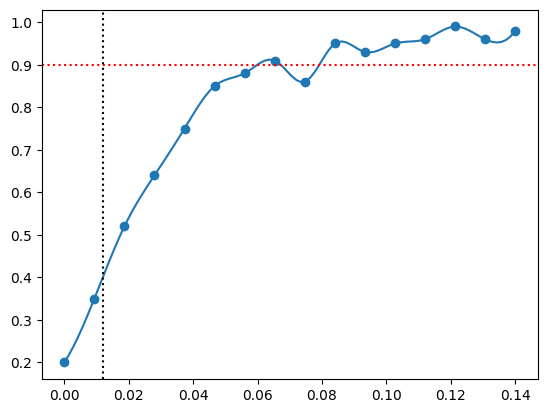


------- Sensitivity and discovery potential with 73 neutrino alerts (average signalness: 45.6 %, min_E: 61 TeV) --------

Sensitivity at 0.079 of flux, expectation of 2.6/73 = 0.04

----------------------------------------------------------------------------------------------------------



100%|██████████| 1600/1600 [01:07<00:00, 23.61it/s]


[{'strength_flux_weight': [0.0]}, {'strength_flux_weight': [2.7137230207673047]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [4.324721039817003]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [2.6077027931035435]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [3.0050778990687923]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.4706493514778627]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {'strength_flux_weight': [0.0]}, {

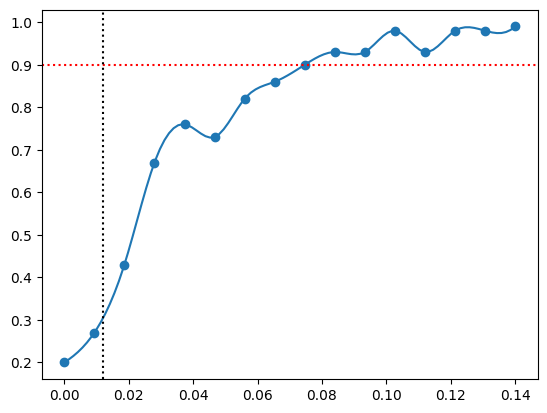


------- Sensitivity and discovery potential with 73 neutrino alerts (average signalness: 45.6 %, min_E: 72 TeV) --------

Sensitivity at 0.075 of flux, expectation of 2.5/73 = 0.03

----------------------------------------------------------------------------------------------------------



 42%|████▏     | 677/1600 [00:27<00:34, 26.93it/s]

In [ ]:
es = np.logspace(np.log10(40),np.log10(500),10)
es = np.linspace(50,150,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        AccretionFlaresSjoertCatalogue(),
        [StrengthFluxWeightHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.14,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/alertstack_results/"
            "sjoert_n10000000_f0.25_s15_update_signalness.pkl"
        ),
        tag="sjoert_zoom",
        max_workers=4,
        chunksize=4,
        n_trials=100
    ))

Found 524 sources in total


100%|██████████| 1600/1600 [04:51<00:00,  5.50it/s]


[{'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [10.827430150839271]}, {'bolometric_fluence_weight': [4.15736427333032]}, {'bolometric_fluence_weight': [2.3263715357924526]}, {'bolometric_fluence_weight': [1.219063267317899]}, {'bolometric_fluence_weight': [8.951923205006727]}, {'bolometric_fluence_weight': [6.086408539877058]}, {'bolometric_fluence_weight': [4.462136702568399]}, {'bolometric_fluence_weight': [13.368506287227074]}, {'bolometric_fluence_weight': [0.7862664557946853]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [6.947956983849706]}, {'bolometric_fluence_weight': [5.9283276525914115]}, {'bolometric_fluence_weight': [3.447540515648606]}, {'bolometric_fluence_weight': [0.5106950231202151]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.743040548670647]}, {'bolometric_fluence_weight': [0.596879688098871]}, {'bolometric_fluence_weight': [0.06524040013284706]}, {'bolometric_fluence_weight': [3.6034522315269

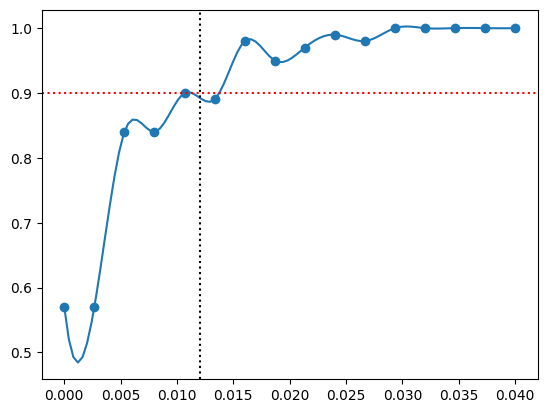


------- Sensitivity and discovery potential with 304 neutrino alerts (average signalness: 47.2 %, min_E: 50 TeV) --------

Sensitivity at 0.014 of flux, expectation of 2.0/304 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [04:45<00:00,  5.61it/s]


[{'bolometric_fluence_weight': [2.413697536302755]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [4.570379442436154]}, {'bolometric_fluence_weight': [2.900781345796834]}, {'bolometric_fluence_weight': [1.8061833354027184]}, {'bolometric_fluence_weight': [1.4797168804262884]}, {'bolometric_fluence_weight': [5.933268241788805]}, {'bolometric_fluence_weight': [2.0528586680607397]}, {'bolometric_fluence_weight': [2.1652631024484505]}, {'bolometric_fluence_weight': [0.5758076811702612]}, {'bolometric_fluence_weight': [5.0457199970062865]}, {'bolometric_fluence_weight': [13.196107675041489]}, {'bolometric_fluence_weight': [1.8451412487853425]}, {'bolometric_fluence_weight': [5.9619418264805715]}, {'bolometric_fluence_weight': [5.530872296061962]}, {'bolometric_fluence_weight': [2.2917785389692877]}, {'bolometric_fluence_weight': [1.8339724993121733]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.20856098155038913]}, {'bolometric_fluence_weigh

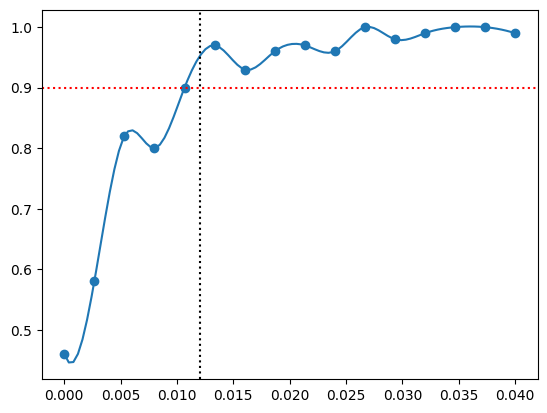


------- Sensitivity and discovery potential with 301 neutrino alerts (average signalness: 47.3 %, min_E: 61 TeV) --------

Sensitivity at 0.011 of flux, expectation of 1.5/301 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


 13%|█▎        | 204/1600 [00:37<04:15,  5.46it/s]


KeyboardInterrupt: 

In [5]:
es = np.logspace(np.log10(40),np.log10(500),10)
es = np.linspace(50,150,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        FlairesCatalogue(),
        [FluencebolHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.04,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/alertstack_results/flaires_n2000000_f0.07_s10.pkl"  
        ),
        tag="flaires_zoom",
        max_workers=4,
        chunksize=4,
        n_trials=100
    ))

100%|██████████| 1600/1600 [11:06<00:00,  2.40it/s]


[{'average_flux_weight': [34.67165109620941]}, {'average_flux_weight': [24.985003359071335]}, {'average_flux_weight': [22.28954332029279]}, {'average_flux_weight': [24.534749557008762]}, {'average_flux_weight': [26.584035249910954]}, {'average_flux_weight': [28.12469638724709]}, {'average_flux_weight': [28.87800038335581]}, {'average_flux_weight': [28.735595703947286]}, {'average_flux_weight': [31.291567897388802]}, {'average_flux_weight': [24.16934496799913]}, {'average_flux_weight': [30.30373477454468]}, {'average_flux_weight': [32.856313295700744]}, {'average_flux_weight': [26.347666827609633]}, {'average_flux_weight': [22.163135679220872]}, {'average_flux_weight': [22.989723549170392]}, {'average_flux_weight': [38.395984269160536]}, {'average_flux_weight': [34.35473606747224]}, {'average_flux_weight': [26.186655961526288]}, {'average_flux_weight': [20.3249524740781]}, {'average_flux_weight': [19.389539065165422]}, {'average_flux_weight': [35.28994184963546]}, {'average_flux_weight'

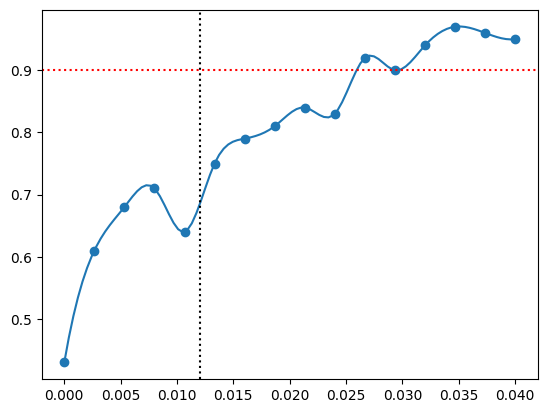


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 50 TeV) --------

Sensitivity at 0.026 of flux, expectation of 4.7/387 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 1600/1600 [11:04<00:00,  2.41it/s]


[{'average_flux_weight': [43.99554727893413]}, {'average_flux_weight': [24.58948052559581]}, {'average_flux_weight': [39.275483202015465]}, {'average_flux_weight': [21.847430276052112]}, {'average_flux_weight': [17.47352922854919]}, {'average_flux_weight': [22.040485723890853]}, {'average_flux_weight': [27.40751540351199]}, {'average_flux_weight': [26.261431123335058]}, {'average_flux_weight': [24.88177644727256]}, {'average_flux_weight': [25.84363389698315]}, {'average_flux_weight': [23.46250783273202]}, {'average_flux_weight': [39.9619877459293]}, {'average_flux_weight': [26.35491208474138]}, {'average_flux_weight': [30.256539842655357]}, {'average_flux_weight': [30.642457639337625]}, {'average_flux_weight': [23.44457140480589]}, {'average_flux_weight': [40.353505666018904]}, {'average_flux_weight': [22.874083564763065]}, {'average_flux_weight': [12.002617183904984]}, {'average_flux_weight': [29.377913240665244]}, {'average_flux_weight': [32.2704828951789]}, {'average_flux_weight': [

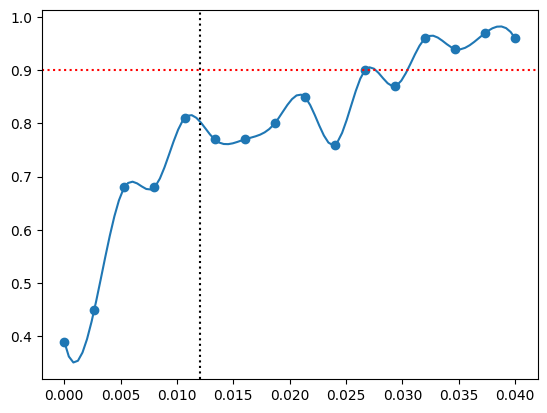


------- Sensitivity and discovery potential with 383 neutrino alerts (average signalness: 46.9 %, min_E: 61 TeV) --------

Sensitivity at 0.030 of flux, expectation of 5.5/383 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 1600/1600 [10:58<00:00,  2.43it/s]


[{'average_flux_weight': [32.24308203037237]}, {'average_flux_weight': [39.35296279571131]}, {'average_flux_weight': [39.89696640299221]}, {'average_flux_weight': [32.01358997496017]}, {'average_flux_weight': [30.335968207746692]}, {'average_flux_weight': [24.078722281227364]}, {'average_flux_weight': [33.561085726814284]}, {'average_flux_weight': [45.91443629827308]}, {'average_flux_weight': [22.494763175372896]}, {'average_flux_weight': [41.20520812929268]}, {'average_flux_weight': [21.245766809897162]}, {'average_flux_weight': [26.533711111643537]}, {'average_flux_weight': [20.17187864479796]}, {'average_flux_weight': [31.42971265522576]}, {'average_flux_weight': [14.575768496968863]}, {'average_flux_weight': [38.55029054538212]}, {'average_flux_weight': [21.60009042829261]}, {'average_flux_weight': [32.225541668760705]}, {'average_flux_weight': [36.09616962577451]}, {'average_flux_weight': [31.77908029037819]}, {'average_flux_weight': [26.90548923450937]}, {'average_flux_weight': [

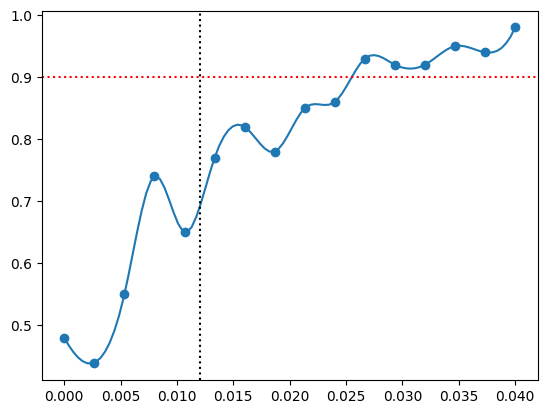


------- Sensitivity and discovery potential with 380 neutrino alerts (average signalness: 46.8 %, min_E: 72 TeV) --------

Sensitivity at 0.026 of flux, expectation of 4.5/380 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 1600/1600 [11:01<00:00,  2.42it/s]


[{'average_flux_weight': [33.56890537052828]}, {'average_flux_weight': [19.194931418272866]}, {'average_flux_weight': [19.699899338804546]}, {'average_flux_weight': [20.897297891459594]}, {'average_flux_weight': [30.47028992091594]}, {'average_flux_weight': [30.477900844867875]}, {'average_flux_weight': [13.752856519660973]}, {'average_flux_weight': [31.610067696737264]}, {'average_flux_weight': [28.879261000074546]}, {'average_flux_weight': [28.35586364352614]}, {'average_flux_weight': [26.38470374294543]}, {'average_flux_weight': [24.706994967701934]}, {'average_flux_weight': [17.590465148803133]}, {'average_flux_weight': [21.806369052225673]}, {'average_flux_weight': [21.593905417939474]}, {'average_flux_weight': [23.39075210148134]}, {'average_flux_weight': [24.156352668561123]}, {'average_flux_weight': [28.62362136049859]}, {'average_flux_weight': [41.949237541298]}, {'average_flux_weight': [21.253250458153595]}, {'average_flux_weight': [33.791488082375146]}, {'average_flux_weight

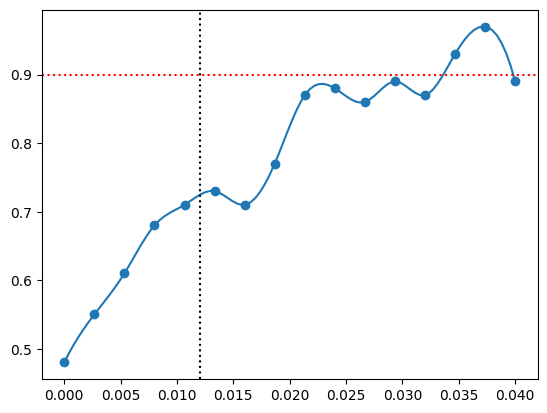


------- Sensitivity and discovery potential with 379 neutrino alerts (average signalness: 46.8 %, min_E: 83 TeV) --------



ValueError: f(a) and f(b) must have different signs

In [5]:
es = np.logspace(np.log10(40),np.log10(500),10)
es = np.linspace(50,150,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        Fermi4FGLBlazarCatalogue(),
        [AverageFluxWeightHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.04,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/New_Updated_Alerts_Stacking/examples/"
            "fermi_blazar_neutrino_alert/cache/2026_01_09-16_21_22.pkl"  
        ),
        tag="fermi_average",
        max_workers=4,
        chunksize=4,
        n_trials=100
    ))

In [4]:
obj = FlairesCatalogue()

Found 524 sources in total


In [5]:
obj.data

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol,bkg_pdf
0,NGC 7392,5.985660,-0.359679,342.95308,-20.60808,57169.940000,8.532,8.467,NaN,NaN,...,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360,1.121052e-07
1,NGC 1566,1.134495,-0.958846,65.00175,-54.93781,58323.830000,6.616,6.503,NaN,NaN,...,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341,6.242265e-08
2,UGC 11487,5.189800,1.108443,297.35363,63.50908,57923.033620,10.853,10.708,NaN,NaN,...,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851,9.190160e-08
3,WISEA J161105.71+023400.3,4.237200,0.044798,242.77370,2.56675,58168.508100,12.044,11.678,NaN,NaN,...,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959,1.212766e-07
4,WISEA J154843.06+220812.6,4.139562,0.386361,237.17944,22.13686,59253.400281,13.625,13.570,NaN,NaN,...,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401,2.213120e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,J185546.08+381941.1,4.955723,0.668951,283.94201,38.32809,57855.260000,15.455,15.322,443829.0,J185546.08+381941.1,...,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003,1.203933e-07
520,J175849.74+585957.2,4.707281,1.029730,269.70731,58.99917,58927.022260,15.779,15.275,14472566.0,J175849.74+585957.2,...,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003,1.788582e-07
521,J175918.34+482759.3,4.709358,0.845901,269.82631,48.46656,58928.850000,15.014,14.404,25813160.0,J175918.34+482759.3,...,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003,2.360361e-07
522,J103622.74+750941.6,2.776728,1.311817,159.09481,75.16158,58047.120000,15.222,14.859,842494.0,J103622.74+750941.6,...,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003,2.216962e-07


In [8]:
cat = obj.scramble()
obj.set_bkg_pdf_per_source(cat)

In [9]:
cat["bkg_pdf"]

0      6.575489e-08
1      5.661406e-08
2      1.308077e-07
3      2.272048e-07
4      1.516687e-07
           ...     
519    1.215585e-07
520    1.011983e-07
521    1.533658e-07
522    1.309502e-07
523    1.152555e-07
Name: bkg_pdf, Length: 524, dtype: float64

In [7]:
cat["bkg_pdf"]

0      1.465548e-07
1      1.560274e-07
2      9.708611e-08
3      3.364273e-08
4      1.041147e-07
           ...     
519    4.580406e-08
520    1.053409e-07
521    2.218276e-07
522    1.383419e-07
523    4.112640e-08
Name: bkg_pdf, Length: 524, dtype: float64

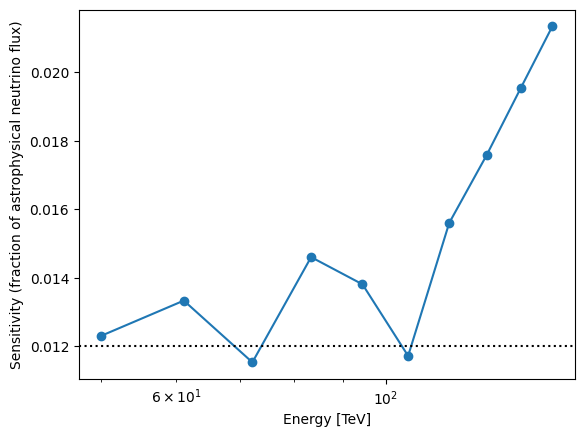

In [8]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires_zoom", dpi=150)

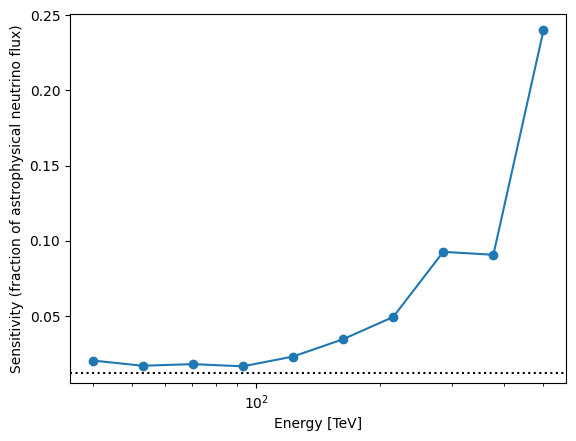

In [16]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires", dpi=150)

In [37]:
agn_analysis = Analyse(
    AstrogeoAGNCatalogue(),
    [AverageFluxWeightHypothesis],
    HealpixNeutrinoAlertCatalogue(),
    cache_dir=os.getcwd(),
    min_E = 0,
    clean_cache=False
)

In [11]:
es = np.array([nu.energy for nu in agn_analysis.fixed_sources])
len(es), es

(365,
 array([ 161.  ,  134.  ,  139.  ,  154.  ,   85.  ,  237.  ,  109.  ,
         151.  ,  126.77,  105.  ,  126.  ,  126.  ,  109.  ,  161.47,
         416.  ,  116.  ,  115.  ,  122.  ,  122.  ,  106.  ,  123.  ,
         231.  ,  140.  ,   62.  ,  113.  ,  214.  ,  109.5 ,  163.  ,
         186.  ,  107.  ,   56.  ,  106.  ,  160.  ,  107.  ,  135.  ,
         107.  ,  208.  ,  184.  ,  439.  ,  144.  ,  110.  ,  110.  ,
         111.  ,  116.  ,  121.26,  208.  ,  168.  ,  193.  ,  202.  ,
         263.  ,  153.  ,  212.  ,  191.  ,  121.  ,  124.  , 3114.  ,
         143.  ,  133.  ,  267.79,   55.  ,  108.  ,  195.  ,  321.  ,
         114.  ,  133.  ,  108.  ,  109.  ,  961.  ,  216.  ,  217.  ,
         118.  ,  105.44,  155.  ,  155.  ,  228.  ,  218.  ,  188.  ,
         115.  ,  374.  ,  152.  ,  188.  ,  168.  ,  140.  ,  110.  ,
         139.  ,  198.  ,  161.  ,   55.  ,  128.  ,  113.  ,  373.  ,
         216.  ,  110.  ,  200.  ,  109.  ,  117.  ,  160.  ,  106.  ,


In [4]:
agn_analysis.set_injection_hypo(AverageFluxWeightHypothesis)

In [31]:
fraction = 0.06
n_steps = 10
n_trials = 100
progression_bar = True
additional_tag = "E_min_100"

fs = []
for step in np.linspace(0.0, fraction, n_steps + 1)[1:]:
    fs += [step for _ in range(n_trials)]

inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]

if 'Healpix' not in type(agn_analysis.fixed_sources).__name__:
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        agn_analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
    )
    
else:
    results = []
    if progression_bar:
        for i in tqdm(range(len(inputs))):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
    else:
        t0 = time.time()
        for i in range(len(inputs)):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
if not progression_bar:
    sys.stderr = sys.__stderr__
    t1 = time.time()
    print(f"Job completed. Time taken:{(t1-t0)/3600} hours")

all_res = dict()

# Combine results into nested dictionaries

for fraction in sorted(list(set(fs))):
    mask = np.array(fs) == fraction
    cut_results = np.array(results)[mask]
    res_dict = cut_results[0]
    for entry in cut_results[1:]:
        for key, val in entry.items():
            res_dict[key] += val

    for key in res_dict.keys():
        res_dict[key] = np.array(res_dict[key])
    all_res[fraction] = res_dict

agn_analysis.all_res = all_res

agn_analysis.dump_results(additional_tag=additional_tag)

100%|██████████| 1000/1000 [08:48<00:00,  1.89it/s]


In [39]:
additional_tag = "E_min_0"
results = glob.glob(agn_analysis.cache_dir + "/" + additional_tag + "*")
new_res = results[0]
old_res = (
    "/data/user/gsommani/New_Updated_Alerts_Stacking/"
    "examples/radio_agn_neutrino_alert/cache/2025_10_27-10_16_09.pkl"
)
with open(new_res, "rb") as f:
    new_res_dict = pickle.load(f)
with open(old_res, "rb") as f:
    old_res_dict = pickle.load(f)

sens_threshold = dict()
for key, val in old_res_dict[0.].items():
    sens_threshold[key] = np.median(val)

In [43]:
levels = [
    ("Background Median", sens_threshold),
]

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in new_res_dict.items():

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in agn_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0.006, 0.06, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")


------- Sensitivity and discovery potential with 365 neutrino alerts (average signalness: 45.1 %) --------

Sensitivity at 0.033 of flux, expectation of 5.4/365 = 0.01

----------------------------------------------------------------------------------------------------------



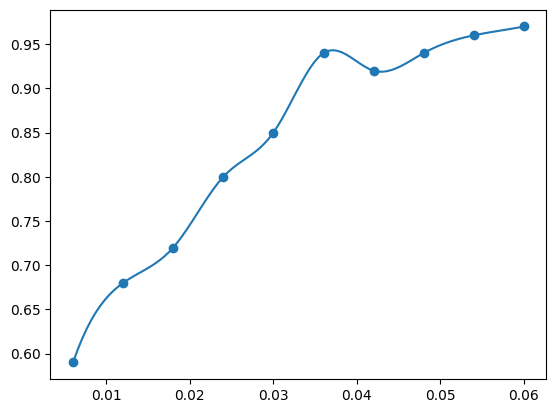

In [41]:
frs = np.linspace(min(fracs), max(fracs), 100)
plt.scatter(fracs, sens, marker="o")
plt.plot(frs, f1(frs))